# AutoField Interactive Playground

Welcome to the AutoField playground! This notebook will guide you step-by-step in creating a simple spatial scenario and running an aggregate program (a hop-count gradient).

## 1. Setup & Imports
Let's import `torch` and the main `autofield` constructs.

In [35]:
import sys
from pathlib import Path

# Add the project root to sys.path so we can import 'autofield' without installing it
root_dir = Path.cwd().parent.parent
if str(root_dir / 'src') not in sys.path:
    sys.path.insert(0, str(root_dir / 'src'))

In [36]:
import torch
import matplotlib.pyplot as plt

from autofield import SpatialScenario, SimulationEngine
from autofield import rep, mux, nbr, minhood
from autofield.dsl import field, AggregateContext
from autofield.utils import get_device

device = get_device()
print(f"Using device: {device}")

Using device: cuda


## 2. Creating the Spatial Scenario
We randomly position some nodes in a 2D space and define a communication radius. Nodes falling within this radius will be connected in the graph.

In [37]:
num_nodes = 15
radius = 0.4
source_idx = 0

# Fix the seed to always get the same example graph
torch.manual_seed(42)
positions = torch.rand(num_nodes, 2, device=device)

scenario = SpatialScenario(
    positions=positions, 
    edge_radius=radius, 
    device=device
)

# Create a mask for the source node (node 0 will be True, others False)
source = scenario.marker(source_idx)

## 3. Topology Visualization
Let's see how the nodes are arranged and the connections (edges) created.

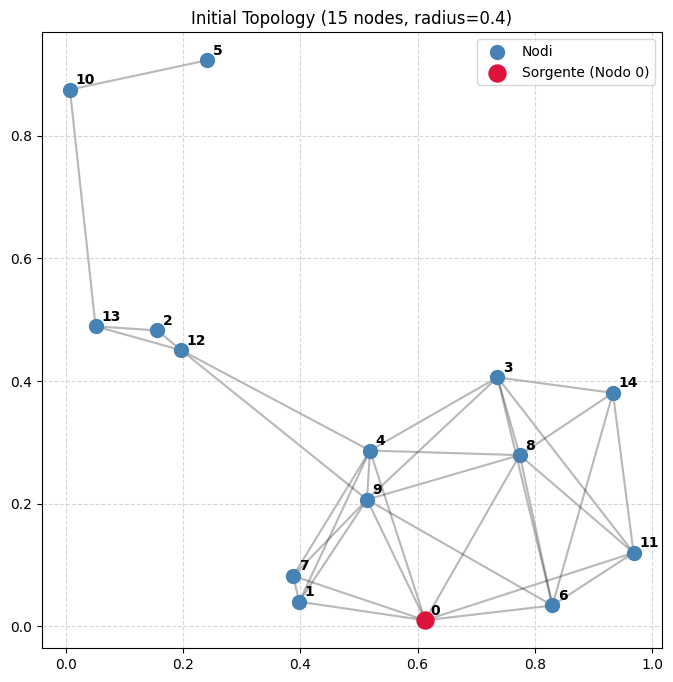

In [38]:
pos = scenario.positions.cpu().numpy()
edges = scenario.edge_index.cpu().numpy()

plt.figure(figsize=(8, 8))

# Draw edges
for i in range(edges.shape[1]):
    src, tgt = edges[0, i], edges[1, i]
    plt.plot([pos[src, 0], pos[tgt, 0]], [pos[src, 1], pos[tgt, 1]], 'k-', alpha=0.15, zorder=1)
             
# Draw normal nodes
plt.scatter(pos[:, 0], pos[:, 1], c='steelblue', s=100, zorder=2, label="Nodi")

# Highlight the source
plt.scatter(pos[source_idx, 0], pos[source_idx, 1], c='crimson', s=150, zorder=3, label=f"Sorgente (Nodo {source_idx})")

# Add labels with IDs
for i in range(len(pos)):
    plt.annotate(str(i), (pos[i, 0], pos[i, 1]), xytext=(4, 4), textcoords='offset points', fontsize=10, fontweight='bold')

plt.title(f"Initial Topology ({num_nodes} nodes, radius={radius})")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Inspecting Edge Messages (Full Repr)
We can see how messages are sent along the graph edges before even running the entire simulation.

In [39]:
# Open a manual context to evaluate an `nbr` expression
ctx = AggregateContext(num_nodes=scenario.num_nodes, edge_index=scenario.edge_index)
with ctx.round():
    # Imagine node 0 is sending the value 0.0, and the others infinity
    node_values = torch.where(source.bool(), 0.0, float('inf'))
    
    # Create the neighborhood expression
    messages = nbr(node_values)
    
    # Use full_repr() to display the Message Grid!
    print("How do the messages look?\n")
    print(messages.full_repr(max_nodes=6))

How do the messages look?

nbr(field) evaluated to edge tensor:
  Shape: [edges=70]
  Message Grid (Row=Source, Col=Target):
      tgt |   0 |   1 | 2 |   3 |   4 | 5
  src     |
  --------+-------------------------------
    0     |   - |   0 | - |   - |   0 | -
    1     | inf |   - | - |   - | inf | -
    2     |   - |   - | - |   - |   - | -
    3     |   - |   - | - |   - | inf | -
    4     | inf | inf | - | inf |   - | -
    5     |   - |   - | - |   - |   - | -
  ... and 9 more nodes not shown. (Showing top-left 6x6 corner)


## 5. Defining the Aggregate Program
We write the function that will be executed by *all* nodes at each round. 
We use:
- `rep` for persistent state
- `mux` for conditional choice (if I am the source, distance is 0)
- `minhood` and `nbr` to collect the minimum value from the neighborhood and add 1

In [40]:
weight = torch.tensor(1.0, device=device)

def distance_to_source(runtime):
    return rep(
        field.inf(),
        lambda d: mux(
            source.to(runtime.scenario.device),
            field.of(0.0),
            minhood(nbr(d + weight))
        )
    )

## 6. Running the Simulation
We assign the program to a `SimulationEngine` and compute the final results.

In [41]:
rounds = 40
print(f"Starting simulation for {rounds} rounds...")

engine = SimulationEngine.from_scenario(scenario)

final_output, _ = engine.run(
    rounds=rounds,
    program=distance_to_source,
    signals={"source": source}
)

print("\nFinal distances from the source (hop-count):")
for i in range(num_nodes):
    d = final_output[i].item()
    print(f"Node {i:2d}: {d if d != float('inf') else 'inf'}")

Starting simulation for 40 rounds...

Final distances from the source (hop-count):
Node  0: 0.0
Node  1: 1.0
Node  2: 3.0
Node  3: 2.0
Node  4: 1.0
Node  5: 5.0
Node  6: 1.0
Node  7: 1.0
Node  8: 1.0
Node  9: 1.0
Node 10: 4.0
Node 11: 1.0
Node 12: 2.0
Node 13: 3.0
Node 14: 2.0


## 7. Visualizing the Result
Finally, let's plot the graph again, but this time we will color the nodes based on the computed hop-count distance and display the distance value on each node.

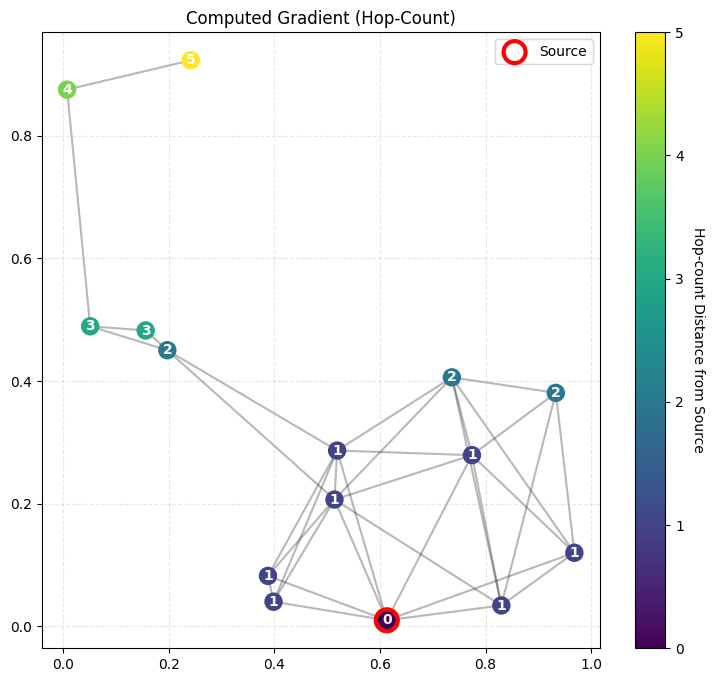

In [42]:
import numpy as np

plt.figure(figsize=(9, 8))

# Draw edges
for i in range(edges.shape[1]):
    src, tgt = edges[0, i], edges[1, i]
    plt.plot([pos[src, 0], pos[tgt, 0]], [pos[src, 1], pos[tgt, 1]], 'k-', alpha=0.15, zorder=1)

# Prepare colors based on distance
distances = final_output.cpu().numpy()

# Handle potential infinity values for disconnected nodes
finite_mask = np.isfinite(distances)
max_dist = distances[finite_mask].max() if np.any(finite_mask) else 1.0

# Draw nodes with a colormap
scatter = plt.scatter(pos[:, 0], pos[:, 1], c=distances, cmap='viridis', 
                      s=150, zorder=2, vmin=0, vmax=max_dist)

cbar = plt.colorbar(scatter)
cbar.set_label('Hop-count Distance from Source', rotation=270, labelpad=15)

# Highlight the source with a distinct border
plt.scatter(pos[source_idx, 0], pos[source_idx, 1], facecolors='none', edgecolors='red', 
            linewidth=3, s=250, zorder=3, label=f"Source")

# Annotate nodes with their computed distance
for i in range(len(pos)):
    d_str = f"{distances[i]:.0f}" if np.isfinite(distances[i]) else "∞"
    plt.annotate(d_str, (pos[i, 0], pos[i, 1]), xytext=(0, 0), 
                 textcoords='offset points', ha='center', va='center', 
                 color='white', fontweight='bold', fontsize=10)

plt.title(f"Computed Gradient (Hop-Count)")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()